In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Import data

In [2]:
STN_ERR = xr.open_dataarray("../DATA/STN_ERR.nc")

In [3]:
ERR_REMOTE = STN_ERR.drop_sel(Product=["PM", "TH"])

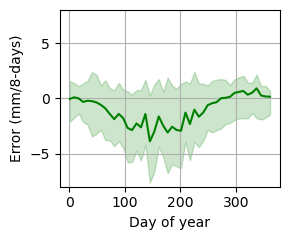

In [4]:
myfig, myax = plt.subplots(figsize=[3,2.5])
ERR_REMOTE.groupby("datetime.dayofyear").mean(dim=["Station", "Product", "datetime"]).plot(ax=myax, label="Remote ERR", color="green")
ERR_R_Q25 = ERR_REMOTE.groupby("datetime.dayofyear").quantile(q=0.25, dim=["Station", "Product", "datetime"])
ERR_R_Q75 = ERR_REMOTE.groupby("datetime.dayofyear").quantile(q=0.75, dim=["Station", "Product", "datetime"])
plt.fill_between(ERR_R_Q25.dayofyear, ERR_R_Q25, ERR_R_Q75, color="green", alpha=0.2)

myax.set_ylabel("Error (mm/8-days)")
myax.set_title("")
myax.set_xlabel("Day of year")
myax.set_ylim([-8, 8])
#myax.legend()
plt.tight_layout()
plt.grid()
plt.savefig("ET4I_ERRdoy.png")